In [1]:
# Section 5.3 - Statistical significance testing
# Paired t-tests compare the same 10 seeds between Task 4 configurations.

from pathlib import Path

import pandas as pd
from scipy.stats import ttest_rel


# Locate the project root.
if Path.cwd().name in {"notebooks", "notebooks-phase2"}:
    PROJECT_ROOT = Path.cwd().parent
else:
    PROJECT_ROOT = Path.cwd()


RESULTS_DIR = (
    PROJECT_ROOT
    / "outputs"
    / "improved_elcs_undersampling"
)


# Load the three Task 4 experiment result files.
full = pd.read_csv(
    RESULTS_DIR / "full_preprocessed_default_runs.csv"
)

undersampled = pd.read_csv(
    RESULTS_DIR / "undersampling_only_default_runs.csv"
)

improved = pd.read_csv(
    RESULTS_DIR / "undersampled_improved_elcs_runs.csv"
)


# Metrics selected as the main evaluation measures in Section 5.2.
metrics = [
    "Recall",
    "PR-AUC",
    "Balanced accuracy",
]


# Store the statistical-test results.
test_results = []


# Comparison 1:
# Tests the effect of introducing undersampling.
for metric in metrics:

    paired = full[
        ["Seed", metric]
    ].merge(
        undersampled[["Seed", metric]],
        on="Seed",
        suffixes=("_default", "_undersampled"),
    )

    t_statistic, p_value = ttest_rel(
        paired[f"{metric}_default"],
        paired[f"{metric}_undersampled"],
    )

    test_results.append({
        "Comparison": "Default vs Default + undersampling",
        "Metric": metric,
        "t-statistic": t_statistic,
        "p-value": p_value,
        "Statistically significant": p_value < 0.05,
    })


# Comparison 2:
# Tests the effect of the improved eLCS parameters.
for metric in metrics:

    paired = undersampled[
        ["Seed", metric]
    ].merge(
        improved[["Seed", metric]],
        on="Seed",
        suffixes=("_undersampled", "_improved"),
    )

    t_statistic, p_value = ttest_rel(
        paired[f"{metric}_undersampled"],
        paired[f"{metric}_improved"],
    )

    test_results.append({
        "Comparison": "Default + undersampling vs Improved + undersampling",
        "Metric": metric,
        "t-statistic": t_statistic,
        "p-value": p_value,
        "Statistically significant": p_value < 0.05,
    })


# Convert the results into a table.
test_results_df = pd.DataFrame(test_results)

display(test_results_df)

,Comparison,Metric,t-statistic,p-value,Statistically significant
0,Default vs Default + undersampling,Recall,-3.223487,1.043093e-02,True
1,Default vs Default + undersampling,PR-AUC,-11.196259,1.386658e-06,True
2,Default vs Default + undersampling,Balanced accuracy,-3.247878,1.003136e-02,True
3,Default + undersampling vs Improved + undersam...,Recall,2.542050,3.160432e-02,True
4,Default + undersampling vs Improved + undersam...,PR-AUC,-20.302492,7.953272e-09,True
5,Default + undersampling vs Improved + undersam...,Balanced accuracy,2.542080,3.160276e-02,True


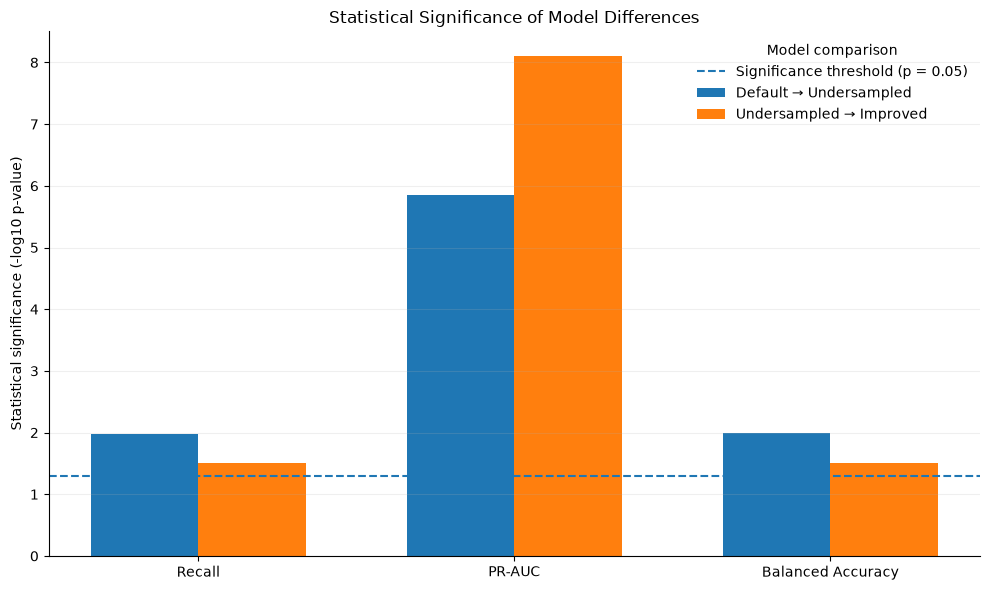

In [7]:
# Figure 5.3.3
# Clean visual summary of the paired t-test results.

import numpy as np
import matplotlib.pyplot as plt


# Copy the statistical-test results.
plot_data = test_results_df.copy()

# Convert p-values to -log10(p).
# Larger values = stronger evidence of a difference.
plot_data["Significance score"] = -np.log10(
    plot_data["p-value"]
)

# Short labels for the two comparisons.
comparison_labels = {
    "Default vs Default + undersampling":
        "Default → Undersampled",

    "Default + undersampling vs Improved + undersampling":
        "Undersampled → Improved",
}

plot_data["Comparison label"] = (
    plot_data["Comparison"]
    .replace(comparison_labels)
)


# Arrange results so each comparison contains
# Recall, PR-AUC, and Balanced Accuracy.
metrics = [
    "Recall",
    "PR-AUC",
    "Balanced accuracy",
]

comparisons = [
    "Default → Undersampled",
    "Undersampled → Improved",
]


fig, ax = plt.subplots(
    figsize=(10, 6)
)

x = np.arange(len(metrics))
width = 0.34


for i, comparison in enumerate(comparisons):

    results = (
        plot_data[
            plot_data["Comparison label"] == comparison
        ]
        .set_index("Metric")
        .reindex(metrics)
    )

    positions = (
        x
        + (i - 0.5) * width
    )

    ax.bar(
        positions,
        results["Significance score"],
        width=width,
        label=comparison,
    )


# p = 0.05 converted to the same scale.
significance_threshold = -np.log10(0.05)

ax.axhline(
    significance_threshold,
    linestyle="--",
    linewidth=1.5,
    label="Significance threshold (p = 0.05)",
)


ax.set_title(
    "Statistical Significance of Model Differences"
)

ax.set_ylabel(
    "Statistical significance (-log10 p-value)"
)

ax.set_xlabel("")

ax.set_xticks(
    x,
    [
        "Recall",
        "PR-AUC",
        "Balanced Accuracy",
    ],
)

ax.legend(
    title="Model comparison",
    frameon=False,
)

ax.grid(
    axis="y",
    alpha=0.2,
)

# Remove unnecessary borders.
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

plt.tight_layout()


FIGURE_DIR = (
    PROJECT_ROOT
    / "outputs"
    / "report_figures"
)

FIGURE_DIR.mkdir(
    parents=True,
    exist_ok=True,
)

plt.savefig(
    FIGURE_DIR
    / "figure_5_3_3_paired_t_test_significance.png",
    dpi=300,
    bbox_inches="tight",
)

plt.show()